### Plotting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
foldseek_3di = pd.read_csv('foldseek/fs_results/fs_calc_full', sep='\t')
foldseek_lol = pd.read_csv('lol_aln/results/lol_calc_full_md_f', sep='\t')
dali_aln = pd.read_csv('dali/final_results/dali_calc_full', sep='\t')
tm_aln_qtm = pd.read_csv('tm_aln/final_results/tm_aln_qtm_final', sep='\t')

In [4]:
alignments = [foldseek_3di, foldseek_lol, dali_aln, tm_aln_qtm]

In [5]:
#lddt calculation
for df in alignments:
    df['query_lddt_filter'] = (df['lddt_all_filtered']*df['aln_len_all_filtered']/df['qlen_all_filtered'])
    df['G_score_lddt_filter'] = np.sqrt(df['lddt_all_filtered'] * df['query_lddt_filter'])

In [6]:
#Search sensitivity + Alignment quality calculation

def calculate_query_scores(df_optimized, mode='G_score_lddt_filter',patience=1,threshold_value=0.5):
    
    if mode == 'query_lddt_filter':
        score_column = 'query_lddt_filter'
        threshold = threshold_value
        denominator = 1 - threshold_value
    elif mode == 'G_score_lddt_filter':
        score_column = 'G_score_lddt_filter'
        threshold = threshold_value
        denominator = 1 - threshold_value
    elif mode == 'lddt_all_filtered':
        score_column = 'lddt_all_filtered'
        threshold = threshold_value
        denominator = 1 - threshold_value
    else:
        raise ValueError(f"Invalid mode: {mode}. Choose 'f1_lddt' or 'tm_score'")
    
    df_work = df_optimized[['query', score_column]].copy()
    
    
    def compute_group_score(group):
        scores = group.values
        total = 0
        below_threshold_count = 0
        
        for score in scores:
            if score < threshold:
                
                below_threshold_count += 1
                
                # Stop if we've reached patience limit
                if below_threshold_count >= patience:
                    break
            else:
                # Add above-threshold values to total
                total += (score - threshold) / denominator
        
        return round(float(total), 6)
    
    query_scores = df_work.groupby('query', sort=False)[score_column].apply(compute_group_score)
    
    return query_scores.to_dict()

In [95]:
#Alignment quality calculation


def calculate_query_aln_quality(df_optimized, mode='G_score_lddt_filter',threshold_value=0.5):
    
    # Set parameters based on mode
    mode_params = {
        'query_lddt_filter': {'column': 'query_lddt_filter', 'threshold': threshold_value, 'denominator': 1 - threshold_value},
        'G_score_lddt_filter': {'column': 'G_score_lddt_filter', 'threshold': threshold_value, 'denominator': 1 - threshold_value},
        'lddt_all_filtered': {'column': 'lddt_all_filtered', 'threshold': threshold_value, 'denominator': 1 - threshold_value},
    }
    
    if mode not in mode_params:
        raise ValueError(f"Invalid mode: {mode}. Choose from {list(mode_params.keys())}")
    
    params = mode_params[mode]
    score_column = params['column']
    threshold = params['threshold']
    denominator = params['denominator']
    
    df_work = df_optimized[['query', score_column]].copy()
    
    def compute_group_score(group):
        # Sort by score in descending order
        sorted_scores = group.sort_values(ascending=False).values
        
        # Sum scores while they're >= threshold, stop when < threshold
        total = 0
        for score in sorted_scores:
            if score >= threshold:
                total += (score - threshold) / denominator
            else:
                break
        
        return round(float(total), 6)
    

    query_scores = df_work.groupby('query', sort=False)[score_column].apply(compute_group_score)
    
    return query_scores.to_dict()

In [17]:
#search_sensitivity + alignment quality #g-score_lddt

mode='G_score_lddt_filter' #chose you score metric here

alignments = [foldseek_3di, foldseek_lol, dali_aln, tm_aln_qtm]
alignment_names = ['foldseek_3di', 'foldseek_lol', 'dali_aln','tm_aln_qtm']

alignments_config = {
    'foldseek_3di': (f'Foldseek_3di_{mode}', mode),
    'foldseek_lol': (f'Foldseek_lol_{mode}', mode),
    'dali_aln': (f'Dali_{mode}', mode),
    'tm_aln_qtm': (f'TMalign_aln_{mode}(query tm_score ranking)', mode)
}

scores_dict_06 = {}
scores_dict_05 = {}
scores_dict_04 = {}

for df, name in zip(alignments, alignment_names):
    # also add your metric here
    df_optimized = df[['query', 'target', 'lddt_all_filtered','query_lddt_filter','G_score_lddt_filter']].copy()
    
    # Remove rows where query == target
    df_optimized.drop(df_optimized[df_optimized['query'] == df_optimized['target']].index, inplace=True)
    col_name, mode = alignments_config[name]
    
    scores_dict_06[col_name] = calculate_query_scores(df_optimized, mode=mode,patience=1,threshold_value=0.6)
    scores_dict_05[col_name] = calculate_query_scores(df_optimized, mode=mode,patience=1,threshold_value=0.5)
    scores_dict_04[col_name] = calculate_query_scores(df_optimized, mode=mode,patience=1,threshold_value=0.4)

g_score_lddt_04 = pd.DataFrame({col_name: pd.Series(scores) 
                               for col_name, scores in scores_dict_04.items()})

g_score_lddt_05 = pd.DataFrame({col_name: pd.Series(scores) 
                               for col_name, scores in scores_dict_05.items()})

g_score_lddt_06 = pd.DataFrame({col_name: pd.Series(scores) 
                               for col_name, scores in scores_dict_06.items()})

g_score_lddt_04 = g_score_lddt_04.reset_index().rename(columns={"index": "query"})
g_score_lddt_05 = g_score_lddt_05.reset_index().rename(columns={"index": "query"})
g_score_lddt_06 = g_score_lddt_06.reset_index().rename(columns={"index": "query"})

In [96]:
#alignment quality

mode='G_score_lddt_filter' #chose you score metric here

alignments = [foldseek_3di, foldseek_lol, dali_aln, tm_aln_qtm]
alignment_names = ['foldseek_3di', 'foldseek_lol', 'dali_aln','tm_aln_qtm']


alignments_config = {
    'foldseek_3di': (f'Foldseek_3di_{mode}', mode),
    'foldseek_lol': (f'Foldseek_lol_{mode}', mode),
    'dali_aln': (f'Dali_{mode}', mode),
    'tm_aln_qtm': (f'TMalign_aln_{mode}(query tm_score ranking)', mode)
}

scores_dict_06 = {}
scores_dict_05 = {}
scores_dict_04 = {}

for df, name in zip(alignments, alignment_names):
    # also add your metric here
    df_optimized = df[['query', 'target', 'lddt_all_filtered','query_lddt_filter', 'G_score_lddt_filter', 'tm_score_query']].copy()
    
    # Remove rows where query == target
    df_optimized.drop(df_optimized[df_optimized['query'] == df_optimized['target']].index, inplace=True)
    col_name, mode = alignments_config[name]
    
    # Calculate scores with the specified mode
    scores_dict_06[col_name] = calculate_query_aln_quality(df_optimized, mode=mode,threshold_value=0.6)
    scores_dict_05[col_name] = calculate_query_aln_quality(df_optimized, mode=mode,threshold_value=0.5)
    scores_dict_04[col_name] = calculate_query_aln_quality(df_optimized, mode=mode,threshold_value=0.4)

aln_quality_g_score_lddt_06 = pd.DataFrame({col_name: pd.Series(scores) 
                               for col_name, scores in scores_dict_06.items()})
aln_quality_g_score_lddt_05 = pd.DataFrame({col_name: pd.Series(scores) 
                               for col_name, scores in scores_dict_05.items()})
aln_quality_g_score_lddt_04 = pd.DataFrame({col_name: pd.Series(scores) 
                               for col_name, scores in scores_dict_04.items()})

aln_quality_g_score_lddt_04 = aln_quality_g_score_lddt_04.reset_index().rename(columns={"index": "query"})
aln_quality_g_score_lddt_05 = aln_quality_g_score_lddt_05.reset_index().rename(columns={"index": "query"})
aln_quality_g_score_lddt_06 = aln_quality_g_score_lddt_06.reset_index().rename(columns={"index": "query"})

In [ ]:
#for the dali we have 2 queries which have Nan values so for every plot we have to
g_score_lddt_04.fillna(0, inplace=True)
g_score_lddt_05.fillna(0, inplace=True)
g_score_lddt_06.fillna(0, inplace=True)
aln_quality_g_score_lddt_06.fillna(0, inplace=True)
aln_quality_g_score_lddt_05.fillna(0, inplace=True)
aln_quality_g_score_lddt_04.fillna(0, inplace=True)

In [12]:
#runtime calculation
import re
from datetime import timedelta

def parse_elapsed_time(time_str):
    """Convert HH:MM:SS format to timedelta"""
    parts = time_str.split(':')
    hours, minutes, seconds = int(parts[0]), int(parts[1]), int(parts[2])
    return timedelta(hours=hours, minutes=minutes, seconds=seconds)

def sum_job_times(filename, job_prefix="0"):
    """Sum all elapsed times for jobs matching the prefix"""
    total_time = timedelta()
    job_count = 0
    
    try:
        with open(filename, 'r') as f:
            lines = f.readlines()
        
        for line in lines[2:]:
            line = line.strip()
            if not line:
                continue
            

            parts = line.split()
            if len(parts) >= 4:
                job_id = parts[0]
                elapsed = parts[3]
                

                if job_id.startswith(job_prefix):
                    try:
                        time_delta = parse_elapsed_time(elapsed)
                        total_time += time_delta
                        job_count += 1
                    except (ValueError, IndexError):
                        print(f"Warning: Could not parse line: {line}")
        
  
        total_time = total_time / 3
        

        total_seconds = int(total_time.total_seconds())
        hours = total_seconds // 3600
        minutes = (total_seconds % 3600) // 60
        seconds = total_seconds % 60
        
        print(f"Job prefix: {job_prefix}")
        print(f"Number of jobs (total entries): {job_count}")
        print(f"Number of unique jobs: {job_count // 3}")
        print(f"Total elapsed time (divided by 3): {hours:02d}:{minutes:02d}:{seconds:02d}")
        print(f"Total seconds: {total_seconds}")
        
        return total_seconds
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found")
    

In [13]:
#runtime for dali
dali_aln_run_time = sum_job_times('sacct_log_run_dali.txt',job_prefix='11467840')

Job prefix: 11467840
Number of jobs (total entries): 6000
Number of unique jobs: 2000
Total elapsed time (divided by 3): 1611:12:28
Total seconds: 5800348


In [14]:
#runtime for tm_aln
tm_aln_run_time = sum_job_times('sacct_log_run_tm_aln.txt',job_prefix='11443567')

Job prefix: 11443567
Number of jobs (total entries): 6000
Number of unique jobs: 2000
Total elapsed time (divided by 3): 334:27:06
Total seconds: 1204026


In [15]:
lol_run_time = 38 * 60 + 48.995 #time= 38m 48s 995ms

In [17]:
foldseek_run_time = 32.518 #time = 32s 518ms

In [18]:
#counting for the parallelization of dali and tm_aln
parallel_dali_run_time = (dali_aln_run_time) / 128  # 128 CPUs
parallel_tm_aln_run_time = tm_aln_run_time / 128  # 128 CPUs

In [98]:
#before plotting account for droping coulmns and differenet nameing conventions
g_score_lddt_04.columns = ['query', 'Foldseek', 'LoLalign', 'Dali','TM-align']
g_score_lddt_05.columns = ['query', 'Foldseek', 'LoLalign', 'Dali','TM-align']
g_score_lddt_06.columns = ['query', 'Foldseek', 'LoLalign', 'Dali','TM-align']
aln_quality_g_score_lddt_06.columns = ['query', 'Foldseek', 'LoLalign', 'Dali','TM-align']
aln_quality_g_score_lddt_05.columns = ['query', 'Foldseek', 'LoLalign', 'Dali','TM-align']
aln_quality_g_score_lddt_04.columns = ['query', 'Foldseek', 'LoLalign', 'Dali','TM-align']

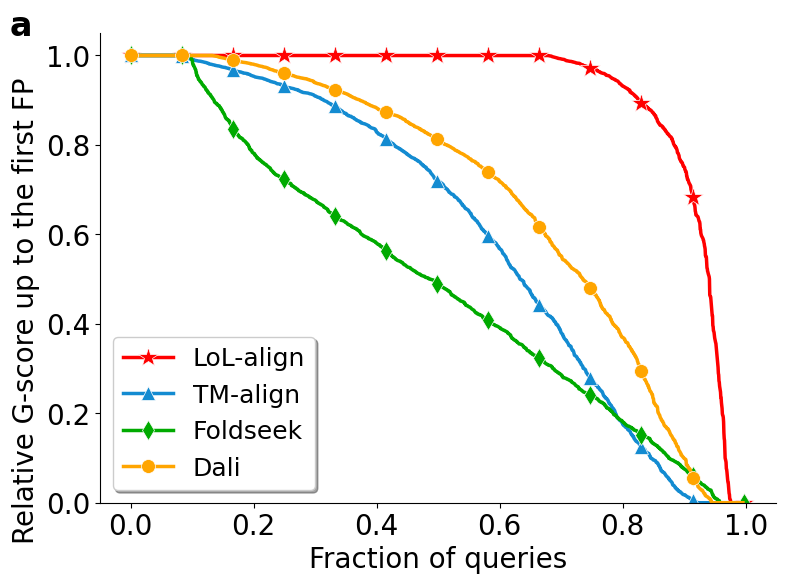

In [23]:
df = g_score_lddt_04.copy()

num_cols = df.select_dtypes(include="number").columns
df["max_score"] = df[num_cols].max(axis=1) + 1e-10  # small constant to avoid division by zero
sens_df = df[num_cols].div(df["max_score"], axis=0)

colors = {
    "Dali": "#FFA500",           
    "TM-align": "#138BD1",       
    "Foldseek": "#00AA00",       
    "LoL-align": "#FF0000",   
    "Foldseek-Tm": "#9932CC"     
}

marker = {
    "Dali": 'o',           
    "TM-align": '^',       
    "Foldseek": 'd',       
    "LoL-align": "*",  
    "Foldseek-Tm": 'v'
}
 

plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 12,
    'axes.labelsize': 20,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})


fig, ax = plt.subplots()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for col in sens_df.columns:

    sorted_vals = sens_df[col].sort_values(ascending=False).reset_index(drop=True)
    n_queries = len(sorted_vals)
    fraction_queries = (sorted_vals.index + 1) / n_queries
    if col=='LoL-align':
        ax.plot(
        
            fraction_queries, 
            sorted_vals.values, 
            label=col,
            color=colors.get(col, '#000000'),  
            marker=marker.get(col),
            markevery=max(1, len(sorted_vals) // 12),  
            markersize=15,
            markeredgewidth=0.5,
            markeredgecolor='white'
        )
    else:
        ax.plot(
        
            fraction_queries, 
            sorted_vals.values, 
            label=col,
            color=colors.get(col, '#000000'),  
            marker=marker.get(col),
            markevery=max(1, len(sorted_vals) // 12),  
            markersize=10,
            markeredgewidth=0.5,
            markeredgecolor='white'
        )

 

ax.set_xlabel("Fraction of queries")
ax.set_ylabel("Relative G-score up to the first FP", y = .41)
ax.set_ylim(0, 1.05)
ax.text(-0.1, 1.05, 'a', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top', ha='right')

plt.legend(frameon=True, fancybox=True, shadow=True, loc='lower left', fontsize=18)
plt.grid(False)

plt.tight_layout()
plt.savefig('sup_fig_a_ROC1_G_score_04.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('sup_fig_a_ROC1_G_score_04.png', dpi=300, bbox_inches='tight', format='png')
plt.show()
 

/tmp/ipykernel_2080567/1253063346.py:81: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, max(df.max())*2)


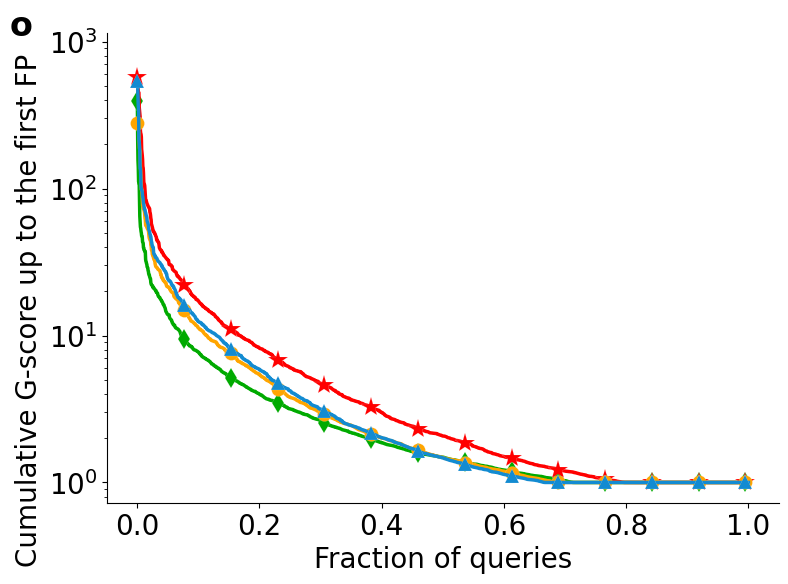

In [ ]:
#Cumulative_rescaled_G_scores


df = g_score_lddt_06.copy()
df.drop('query', axis=1, inplace=True)
df = df + 1

colors = {
    "Dali": "#FFA500",           
    "TM-align": "#138BD1",       
    "Foldseek": "#00AA00",       
    "LoLalign": "#FF0000"  
        
}

marker = {
    "Dali": 'o',           
    "TM-align": '^',       
    "Foldseek": 'd',       
    "LoLalign": "*"
    
}
 

plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 12,
    'axes.labelsize': 20,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})


fig, ax = plt.subplots()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for col in df.columns:
    sorted_vals = df[col].sort_values(ascending=False).reset_index(drop=True)
    n_queries = len(sorted_vals)
    fraction_queries = (sorted_vals.index + 1) / n_queries

    if col=='LoL-align':
        ax.plot(
        
            fraction_queries, 
            sorted_vals.values, 
            label=col,
            color=colors.get(col, '#000000'),
            marker=marker.get(col),
            markevery=max(1, len(sorted_vals) // 13),  
            markersize=15,
            markeredgewidth=0.1,
            markeredgecolor='white'
        )
    else:
        ax.plot(
        
            fraction_queries, 
            sorted_vals.values, 
            label=col,
            color=colors.get(col, '#000000'),
            marker=marker.get(col),
            markevery=max(1, len(sorted_vals) // 13), 
            markersize=10,
            markeredgewidth=0.1,
            markeredgecolor='white'
        )

 

ax.set_xlabel("Fraction of queries")
ax.set_ylabel("Cumulative G-score up to the first FP",y = .41)
ax.text(-0.11, 1.05, 'o', transform=ax.transAxes, fontsize=24, fontweight='bold', va='top', ha='right')
ax.set_yscale('log')
ax.set_ylim(0, max(df.max())*2)

plt.grid(False)

plt.tight_layout()
plt.savefig('sup_fig_o_Cumulative_G_scores_06.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('sup_fig_o_Cumulative_G_scores_06.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

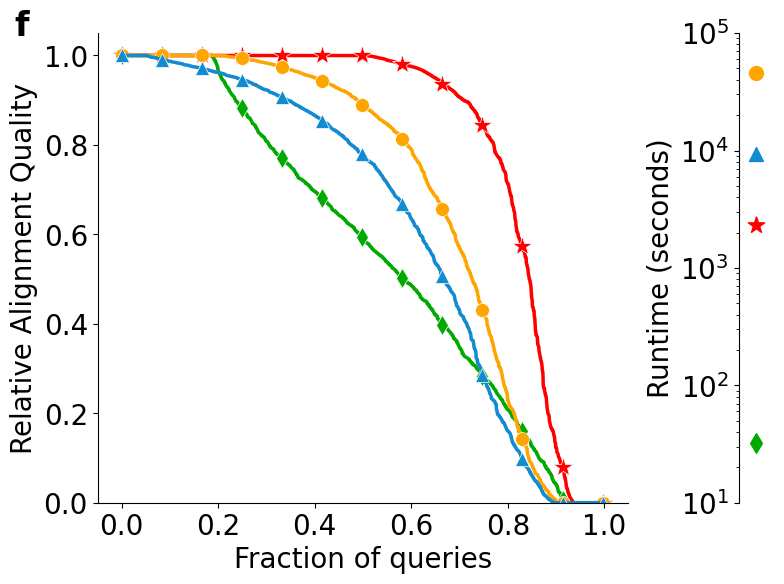

In [ ]:
#alnment quality plot
df = aln_quality_g_score_lddt_05.copy()

methods = ['Dali', 'TM-align','LoLalign','Foldseek']
runtimes = [parallel_dali_run_time, parallel_tm_aln_run_time, lol_run_time, foldseek_run_time]
num_cols = df.select_dtypes(include="number").columns
df["max_score"] = df[num_cols].max(axis=1) + 1e-10  # small constant to avoid division by zero
sens_df = df[num_cols].div(df["max_score"], axis=0)

colors = {
    "Dali": "#FFA500",           
    "TM-align": "#138BD1",       
    "Foldseek": "#00AA00",       
    "LoLalign": "#FF0000",   
    "Foldseek-Tm": "#9932CC"     
}

marker = {
    "Dali": 'o',           
    "TM-align": '^',       
    "Foldseek": 'd',       
    "LoLalign": "*",  
    "Foldseek-Tm": 'v'
}
 
plt.rcParams.update({
    'figure.figsize': (8, 6),
    'font.size': 12,
    'axes.labelsize': 20,
    'axes.titlesize': 16,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 14,
    'lines.linewidth': 2.5,
    'grid.alpha': 0.3,
    'figure.dpi': 100
})

fig, (ax1, ax2) = plt.subplots(1, 2, gridspec_kw={'width_ratios': [15, 1]})

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for col in sens_df.columns:

    sorted_vals = sens_df[col].sort_values(ascending=False).reset_index(drop=True)
    n_queries = len(sorted_vals)
    fraction_queries = (sorted_vals.index + 1) / n_queries
    if col=='LoL-align':
        ax1.plot(
        
            fraction_queries, 
            sorted_vals.values, 
            label=col,
            color=colors.get(col, '#000000'),
            marker=marker.get(col),
            markevery=max(1, len(sorted_vals) // 12),
            markersize=15,
            markeredgewidth=0.5,
            markeredgecolor='white'
        )
    else:
        ax1.plot(
        
            fraction_queries, 
            sorted_vals.values, 
            label=col,
            color=colors.get(col, '#000000'),
            marker=marker.get(col),
            markevery=max(1, len(sorted_vals) // 12),
            markersize=10,
            markeredgewidth=0.5,
            markeredgecolor='white'
        )

 

ax1.set_xlabel("Fraction of queries")
ax1.set_ylabel("Relative Alignment Quality")
ax1.set_ylim(0, 1.05)
ax1.text(-0.13, 1.05, 'f', transform=ax1.transAxes, fontsize=24, fontweight='bold', va='top', ha='right')



ax2.set_yscale('log')
for i, method in enumerate(methods):
    if method=='LoLalign':
        ax2.scatter(0, runtimes[i], 
               marker=marker[method], 
               color=colors[method], 
               s=150, 
               label=method)
    else:
        ax2.scatter(0, runtimes[i], 
               marker=marker[method], 
               color=colors[method], 
               s=100, 
               label=method)

ax2.set_xlim(-0.5, 0.5)
ax2.set_ylim(10, 1e5)
ax2.set_xticks([])
ax2.set_ylabel("Runtime (seconds)")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.grid(True, axis='y', alpha=0.3)

plt.grid(False)

plt.tight_layout()
plt.savefig('main_fig_f_Alignment_quality_and_runtime_05.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('main_fig_f_Alignment_quality_and_runtime_05.png', dpi=300, bbox_inches='tight', format='png')
plt.show()